In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import statistics
import numpy as np
pathToFolder = ""
plt.rcParams.update({'font.size': 10})

results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

all_throughput_results = []
all_median_fairness_results = []
all_max_fairness_results = []
all_time_results = []
all_first2_results = []

util_with_udp_array = []

labels = []

fifo_or_cebinae = ""

In [2]:
def plot():
    # throughput calculation
    time_1 = []
    time_2 = []
    time_3 = []
    time_4 = []
    throughput_array_1 = []
    throughput_array_2 = []
    throughput_array_3 = []
    throughput_array_4  = []
    throughput_array_udp = []
    packet_drop_1 = []
    packet_drop_2 = []
    packet_drop_3 = []
    packet_drop_4 = []
            
    # if any file is does not have entries that go until [duration--30s], print error and change experiments    
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-1.out', 'r') as rf:
        last_time_of_file = float(rf.readlines()[-1][0:4])
        if (last_time_of_file < 29):
            print("error in file 0-0-1.out")
            print(last_time_of_file)
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-2.out', 'r') as rf:
        last_line_of_file = rf.readlines()[-1]
        last_time_of_file = float(last_line_of_file.split(" IP", 1)[0])
        if (last_time_of_file < 29):
            print("error in 0-0-2.out")
            print(last_time_of_file)

    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-3.out', 'r') as rf:
        last_time_of_file = float(rf.readlines()[-1][0:4])
        last_time_of_file = float(last_line_of_file.split(" IP", 1)[0])
        if (last_time_of_file < 29):
            print("error in 0-0-3.out")
            print(last_time_of_file)

    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-4.out', 'r') as rf:
        last_time_of_file = float(rf.readlines()[-1][0:4])
        last_time_of_file = float(last_line_of_file.split(" IP", 1)[0])
        if (last_time_of_file < 29):
            print("error in 0-0-4.out")
            print(last_time_of_file)

    ################################################ throughput ###########################################################
    # # # # # # # # # # # # # # # # # # # # # # # #  four flows # # # # # # # # # # # # # # # # # # # # # # # # # # #

    time_total_throughput = []
    total_throughput_array = []

    prev_recorded_time: float = 0
    total_time: float = 0
    total_size: float = 0
    time_index = 0.1
    total_throughput_array = []

    # total throughput

    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-full-throughput-sorted.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size


            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_total_throughput.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)


                total_throughput_array.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time


    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now

    # throughput 1
    prev_seq_number: float = 0
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-1.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_1.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size


            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_1.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)


                throughput_array_1.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    # throughput 2

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    prev_seq_number: float = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-2.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            # bookmark first_index_in_array_from_data_2 for throughput calculations later (measuring throughput of first second)
            first_index_in_array_from_data_2 = first_index_in_array_from_data
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-2.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_2.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_2.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_2.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    time_index = 0.1
    index = 0
    inserted_all_new_indices = False
    # compare time_index (0.1) to first time in file 0-0-2 (time when first packet is received)
    while (time_index < first_index_in_array_from_data):
        # insert time_index in time array to fill time (to match length of time_1)--match flow start time
        time_2.insert(index, round(time_index, 2))
        throughput_array_2.insert(index, 0)
        index += 1
        time_index += 0.1
        # when time_index has reached the first time in the file (when flow starts), stop inserting new values
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    # if flow stops just before 29.9 (between 19 and 29.9--see above for error for flow stopping before 19s)
    # append time_index and throughput = 0 until array lengths are the same
    last_time_index = time_2[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_2.append(round(last_time_index, 2))
        throughput_array_2.append(0)


    # throughput 3

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    prev_seq_number: float = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-3.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-3.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_3.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_3.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_3.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_3.insert(index, round(time_index, 2))
        throughput_array_3.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_3[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_3.append(round(last_time_index, 2))
        throughput_array_3.append(0)

    # throughput 4

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    prev_seq_number: float = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-4.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-4.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_4.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_4.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_4.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_4.insert(index, round(time_index, 2))
        throughput_array_4.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_4[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_4.append(round(last_time_index, 2))
        throughput_array_4.append(0)
  
    # udp
        # udp
    time_udp_1 = []
    throughput_array_udp_1 = []
    time_udp_2 = []
    throughput_array_udp_2 = []
    time_udp_3 = []
    throughput_array_udp_3 = []
        
    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-12-0-0.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-12-0-0.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_udp_1.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_udp_1.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

        time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_udp_1.insert(index, round(time_index, 2))
        throughput_array_udp_1.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_udp_1[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_udp_1.append(round(last_time_index, 2))
        throughput_array_udp_1.append(0)

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-13-0-0.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-13-0-0.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_udp_2.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_udp_2.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

        time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_udp_2.insert(index, round(time_index, 2))
        throughput_array_udp_2.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_udp_2[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_udp_2.append(round(last_time_index, 2))
        throughput_array_udp_2.append(0)

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-14-0-0.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-14-0-0.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_udp_3.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_udp_3.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

        time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_udp_3.insert(index, round(time_index, 2))
        throughput_array_udp_3.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_udp_3[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_udp_3.append(round(last_time_index, 2))
        throughput_array_udp_3.append(0)
        
        
#      # udp
#     time_udp = []
#     throughput_array_udp = []
        
#     prev_time = 0
#     total_time = 0
#     total_size = 0
#     prev_recorded_time = 0
#     last_time = 0
#     time_index = 0.1 # not used right now
#     first_index_in_array_from_data = 0
#     # used to calculate where time_index should be
#     with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-6.out', 'r') as rf:
#         for line in rf:
#             time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
#             first_index_in_array_from_data = time_index
#             break
#     with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-6.out', 'r') as rf:
#         for line in rf:
#             # current time
#             total_time = float(line.split(" IP", 1)[0])

#             # current size
#             currentLineToSplit = line.split("length ", 1)[1]
#             if (line.split("length ", 1)[1].__contains__(":")):
#                 size = int(currentLineToSplit.split(": HTTP")[0]) + 40
#             else:
#                 size = int(line.split("length ", 1)[1]) + 28
#             size = size * 8
#             total_size += size

#             if (total_time >= time_index):

#                 # add 100 ms interval to time array
#                 time_udp.append(round(time_index, 2))

#                 # add throughput to throughput array
#                 throughput = (total_size - size) / 0.1 # throughput (size / time)

#                 throughput_array_udp.append(throughput / 1000000) # convert bps to Mbps

#                 time_index += 0.1
#                 total_size = size
#                 prev_recorded_time = last_time
#             last_time = total_time

#         time_index = 0.1
#     index = 0
#     while (time_index < first_index_in_array_from_data):
#         time_udp.insert(index, round(time_index, 2))
#         throughput_array_udp.insert(index, 0)
#         index += 1
#         time_index += 0.1
#         if (time_index == first_index_in_array_from_data):
#             inserted_all_new_indices = True

#     last_time_index = time_udp[-1]
#     while (last_time_index < last_time_of_file):
#         last_time_index += 0.1
#         time_udp.append(round(last_time_index, 2))
#         throughput_array_udp.append(0)

#     ############################### queue #######################################################
#     line_number = 0
#     prev_sign = "-"
#     duplicate_line = 0 

#     dropped_packets = [] # array that contains all times where packets were dropped
#     dropped_packets_markers = []
#     prev_time = 0

#     with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-full_sorted_duplicates_TCP.out', 'r') as file:
#         for line in file:
#             line_number += 1
#             adjusted_size = 0

#             sign = line.split(" ", 1)[0]
#             temp_time = line.split(" IP", 1)[0]
#             time = float(temp_time.split(" ")[1])

#             # find size to add to queue
#             currentLineToSplit = line.split("length ", 1)[1]
#             if (line.split("length ", 1)[1].__contains__(":")):
#                 size = int(currentLineToSplit.split(": HTTP")[0]) + 40
#             else:
#                 size = int(line.split("length ", 1)[1]) + 28

#             size = size * 8
#             adjusted_size += size
#             # if it's TCP traffic, check that signs do not match
#             if (not line.__contains__("UDP")):
#                 if (prev_sign == "-" and sign != "+"):
#                     duplicate_line += 1
#                     dropped_packets.append(line)
#                     dropped_packets_markers.append(prev_time)
#                 elif (prev_sign == "+" and sign != "-"):
#                     duplicate_line += 1
#                     dropped_packets.append(line)
#                     dropped_packets_markers.append(prev_time)

#             prev_sign = sign
#             prev_line = line
#             prev_time = time

    # total with all udp

    total_throughput_with_all_udp = []
    

#     for index in range (0, len(time_1)):
#         total_throughput_with_all_udp.append(total_throughput_array[index] + throughput_array_udp_1[index] + throughput_array_udp_2[index] + throughput_array_udp_3[index])

            
    # creating new np arrays so that slice operation can be performed
    np_array_1 = np.array(throughput_array_1)
    np_array_2 = np.array(throughput_array_2)
    np_array_3 = np.array(throughput_array_3)
    np_array_4 = np.array(throughput_array_4)  
    
#     np_throughput_array_udp = np.array(throughput_array_udp)

    # calculate ratio between max/min of four flows using slicing window
    for index in range(40, len(time_1)):
        # slice syntax: basic slice syntax is i:j:k where i is the starting index, j is the stopping index, and k is the step
        throughput_mean_array = np.array([statistics.mean(np_array_1[index:index + 20:1]), statistics.mean(np_array_2[index:index + 20:1]), statistics.mean(np_array_3[index:index + 20:1]), statistics.mean(np_array_4[index:index + 20:1])])
        max = throughput_mean_array.max()
        min = throughput_mean_array.min()
        if (min != 0):
            ratio = max / min
        else:
            ratio = 0

    # find utilization from 6s--> (total throughput)
    utilization_array_total_throughput = []
    for index in range (60, len(time_1)):  
#         utilization_array_total_throughput.append(np_throughput_array_udp[index] + throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
        utilization_array_total_throughput.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
    util_after_60_total_throughput = statistics.mean(utilization_array_total_throughput)
#     print("utilization 6s--> (total throughput): " + str(statistics.mean(utilization_array_total_throughput)))

    # find utilization of last 5 seconds
    utilization_array = []
    for index in range (len(time_1) - 50, len(time_1)):  
#         utilization_array.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index] + throughput_array_udp[index])
        utilization_array.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
    util_last5 = statistics.mean(utilization_array)
#     print("utilization last 5 seconds: " + str(statistics.mean(utilization_array)))

#     utilization_array_with_udp = []
#     for index in range (len(time_1) - 50, len(time_1)):  
#         utilization_array_with_udp.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index] + throughput_array_udp[index])
# #         utilization_array.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
#     util_with_udp_last5 = statistics.mean(utilization_array_with_udp)
# #     print("utilization last 5 seconds: " + str(statistics.mean(utilization_array)))
#     util_with_udp_array.append(util_with_udp_last5)


    # calculate throughput of first flow for 0-2s
    utilization_array_0_2s = []
    for index in range (0, time_1.index(round(first_index_in_array_from_data_2, 1))):
        utilization_array_0_2s.append(throughput_array_1[index])
        util_first2 = statistics.mean(utilization_array_0_2s)

    ratio_array = []

    # calculate ratio between max/min of four flows using slicing window for 15s-18s
    for index in range(len(time_1) - 50, len(time_1)):
        # slice syntax: basic slice syntax is i:j:k where i is the starting index, j is the stopping index, and k is the step
        if ((index + 20) <= len(time_1)): # ensure that there is enough room for slicing window (15-18s)
            throughput_mean_array = np.array([statistics.mean(np_array_1[index:index + 20:1]), statistics.mean(np_array_2[index:index + 20:1]), statistics.mean(np_array_3[index:index + 20:1]), statistics.mean(np_array_4[index:index + 20:1])])

        max = throughput_mean_array.max()
        min = throughput_mean_array.min()
        if (min != 0):
            ratio = max / min
        else:
            ratio = 0
            print("Replace this iteration: ", iteration)
        ratio_array.append(ratio)

    ratio_array_np = np.array(ratio_array)

#     results_throughput.append(statistics.mean(utilization_array_with_udp))
    results_throughput.append(statistics.mean(utilization_array))
    results_median_fairness.append(statistics.median(ratio_array))
    results_max_fairness.append(ratio_array_np.max())
    results_first2.append(util_first2)

    # raw fifo only: assigning Raw FIFO median fairness ratio to be used as constraint
    if (raw_fifo):
        rawFIFOMedianFairnessRatio = statistics.median(ratio_array)
    
#     print("median ratio:", statistics.median(ratio_array))
#     print("max ratio: ", ratio_array_np.max())
#     print("udp:", statistics.median(throughput_array_udp))
    
    if (show_plot):
            ################################### plot throughput--and dropped packets (Mbps) #########################################################
        plt.plot(time_1, throughput_array_1, label="Flow 1")
        plt.plot(time_2, throughput_array_2, label="Flow 2")
        plt.plot(time_3, throughput_array_3, label="Flow 3")
        plt.plot(time_4, throughput_array_4, label="Flow 4")
        plt.plot(time_udp_1, throughput_array_udp_1, label="UDP", color='hotpink', alpha=0.5)
        plt.plot(time_udp_2, throughput_array_udp_2, label="UDP", color='gold', alpha=0.5)
        plt.plot(time_udp_3, throughput_array_udp_3, label="UDP", color='indigo', alpha=0.5)
        plt.plot(time_total_throughput, total_throughput_array, label="Total Throughput", color='black')
#         plt.plot(time_total_throughput, total_throughput_with_all_udp, color='grey')
        plt.plot(packet_drop_1, np.full((len(packet_drop_1)), -3, dtype=int), 'bo') # dropped packets
        plt.plot(packet_drop_2, np.full((len(packet_drop_2)), 3, dtype=int), 'o', color='orange') # dropped packets
        plt.plot(packet_drop_3, np.full((len(packet_drop_3)), 0, dtype=int), 'go') # dropped packets
        plt.plot(packet_drop_4, np.full((len(packet_drop_4)), 6, dtype=int), 'ro') # dropped packets

#     plt.legend(['Flow 1', 'Flow 2', 'Flow 3', 'Flow 4', 'Total Throughput'], loc='upper left', bbox_to_anchor=(1, 1))
        plt.xlabel("Time (s)")
        plt.ylabel("Throughput (Mbps)")
        yticks = np.arange(0, 110, 10)
        plt.yticks(yticks)
    #     plt.title("Tax Constant: " + taxConstant + " Median Fairness: " + str(round(median_fairness, 2)))
        plt.show()
        print("median ratio:", statistics.median(ratio_array))

    return results_throughput, results_median_fairness, results_max_fairness, results_first2

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.07516928
median fairness: 2.864992358916531
max fairness: 3.2299677971009104


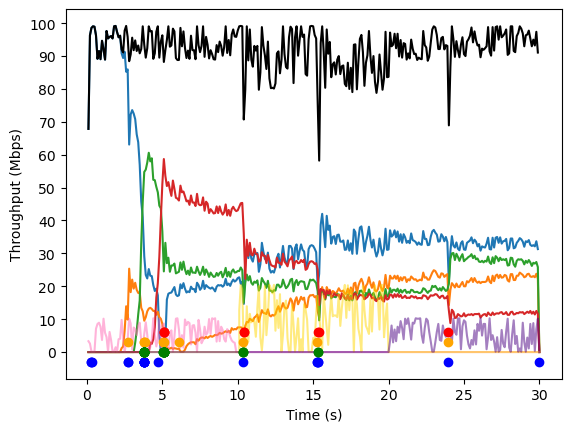

median ratio: 2.80813959355008


([94.1701632,
  94.8939264,
  93.422592,
  93.4868736,
  94.3534848,
  93.660672,
  95.0629632,
  93.1416576,
  95.0320128,
  93.5273472,
  94.8939264],
 [2.010195469555075,
  2.80813959355008,
  4.078132344773644,
  2.9218451242829824,
  2.6994266994266995,
  4.149102073901635,
  4.724430626311058,
  2.5299376515476,
  1.7230871149387215,
  6.518687329079308,
  2.80813959355008],
 [2.102032682343563,
  2.8922436231129622,
  4.671740569159497,
  3.1273699562469615,
  2.8032454361054766,
  4.727150537634409,
  5.178694158075602,
  3.3325656379548594,
  1.754599097535578,
  7.3987975951903815,
  2.8922436231129622],
 [91.07148190476191,
  94.08509090909091,
  91.87075047619048,
  92.36983272727272,
  90.93488,
  93.4126019047619,
  94.6099490909091,
  93.13963789473684,
  94.03614476190477,
  93.274016,
  94.08509090909091])

In [3]:
iteration = 1
taxConstant = "RawFIFO"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = True
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.75250688
median fairness: 3.4748005666144786
max fairness: 12.146367812567432


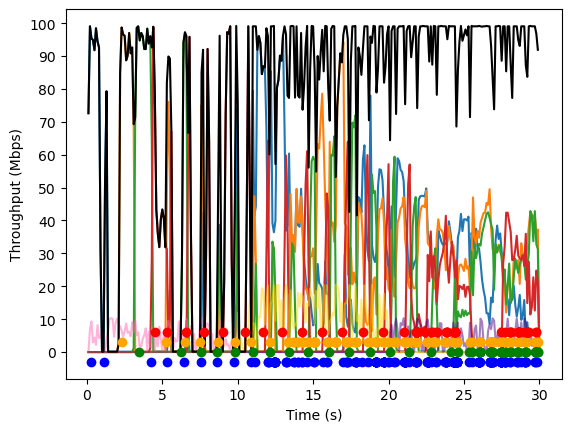

median ratio: 3.273130544993663


([95.493888,
  94.7939328,
  93.0488064,
  94.886784,
  94.6058496,
  94.0225536,
  95.3534208,
  94.148736,
  95.4915072,
  95.6795904,
  95.3534208],
 [1.9913657770800628,
  2.5284006253030102,
  12.373140107306819,
  1.552783262480272,
  6.9445606694560675,
  8.466214890137241,
  3.273130544993663,
  15.433541365793275,
  2.21169432625521,
  3.676470588235294,
  3.273130544993663],
 [6.187686196623634,
  2.768617021276596,
  43.456250000000004,
  2.0967374810318664,
  21.484782608695653,
  15.304421768707483,
  312.79999999999995,
  36.88,
  3.4853700516351123,
  8.98831385642738,
  312.79999999999995],
 [44.991392,
  47.14634105263158,
  39.759573333333336,
  46.657315555555556,
  47.69768421052631,
  40.706472727272725,
  45.092576,
  42.789152,
  41.997536,
  47.62876631578948,
  45.092576])

In [4]:
iteration = 1
taxConstant = "50000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.5808512
median fairness: 1.673103848260018
max fairness: 2.106113178521835


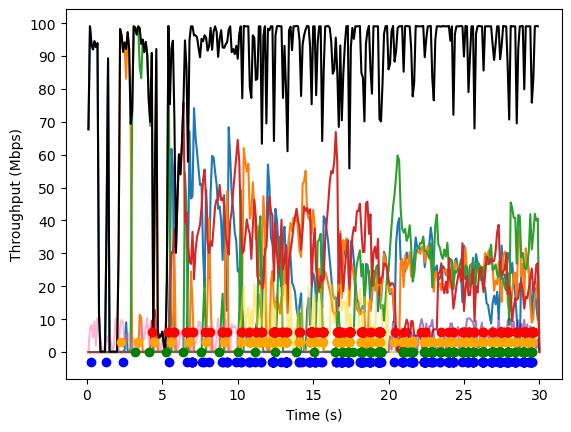

median ratio: 1.597056432845951


([94.9486848,
  93.910656,
  95.922432,
  94.6201344,
  94.505856,
  94.3844352,
  93.59639039999999,
  94.862976,
  95.0034432,
  94.053504,
  93.910656],
 [1.5397830018083183,
  1.597056432845951,
  2.1480061349693247,
  1.2584562012142237,
  1.2322292366559422,
  1.777695988222304,
  7.029810298102981,
  1.7491512636740851,
  3.2478632478632474,
  1.3965089019785042,
  1.597056432845951],
 [2.130369816959283,
  1.8386891504931595,
  283.35,
  2.05589063128267,
  1.34640522875817,
  2.081856540084388,
  15.885786802030458,
  2.9012494961708986,
  5.1532846715328455,
  1.8406079501169135,
  1.8386891504931595],
 [36.902613333333335,
  38.717984,
  35.099168,
  38.97643789473684,
  42.72899555555556,
  40.642997894736844,
  36.77733052631579,
  33.84158476190476,
  39.455395555555555,
  39.134624,
  38.717984])

In [5]:
iteration = 1
taxConstant = "70000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.76012544
median fairness: 1.7746506900253638
max fairness: 3.0604189936878203


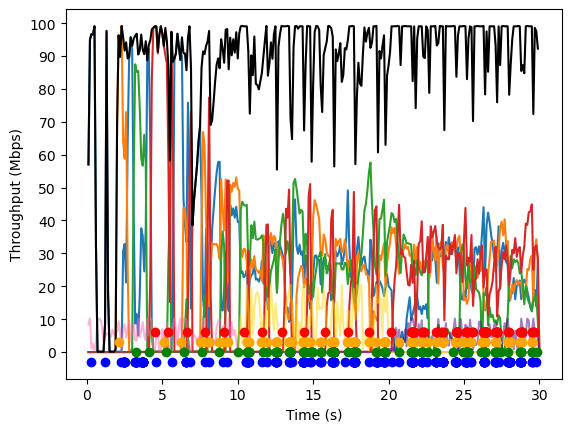

median ratio: 1.7441185949081535


([94.1273088,
  95.1177216,
  95.065344,
  94.9082112,
  95.1867648,
  94.3939584,
  94.851072,
  94.6653696,
  94.9724928,
  94.3130112,
  94.3130112],
 [7.341075794621027,
  1.1126014541551266,
  1.8501055200922067,
  1.3966085257900456,
  3.370045216873523,
  1.8051827851425744,
  1.7330255271892554,
  1.4290067769758845,
  14.872564640876421,
  1.7441185949081535,
  1.7441185949081535],
 [42.36363636363636,
  1.2904422253922967,
  22.32363636363636,
  1.5841618100788482,
  3.9419999999999993,
  2.9031630170316305,
  1.771838331160365,
  1.5650618087182824,
  22.08080808080808,
  3.2176749703440097,
  3.2176749703440097],
 [30.284,
  31.85909894736842,
  32.676704,
  31.783915789473685,
  33.43064888888889,
  34.1521852631579,
  33.60920888888889,
  32.366585263157894,
  32.206496,
  33.41742222222222,
  33.41742222222222])

In [6]:
iteration = 1
taxConstant = "100000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.82947072
median fairness: 1.2022858391459845
max fairness: 1.6434196672038213


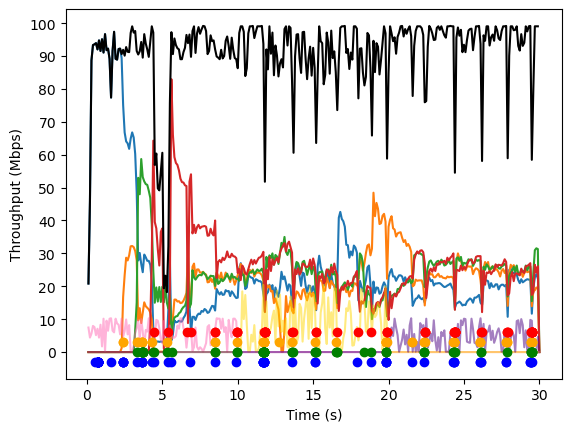

median ratio: 1.1453957996768982


([94.0439808,
  93.3440256,
  94.3606272,
  93.0011904,
  93.5987712,
  94.2344448,
  94.3772928,
  93.101184,
  94.0820736,
  94.1511168,
  94.0439808],
 [1.1453957996768982,
  1.0743449842751458,
  1.8242660560436632,
  1.7546409095388795,
  1.5687935467598093,
  1.259175878615071,
  2.015881857612685,
  1.0874881344413048,
  1.1022575598491606,
  1.090490646728537,
  1.1453957996768982],
 [1.5013623978201633,
  1.3405979323833472,
  3.324531516183986,
  2.2470730722648367,
  1.6849008317338454,
  1.8084967320261436,
  2.0490121580547114,
  1.1382949180783117,
  1.3379310344827586,
  1.601938502673797,
  1.5013623978201633],
 [86.0547961904762,
  87.56830476190477,
  86.94329263157894,
  86.53571555555556,
  88.24286476190476,
  86.64256,
  87.17510736842105,
  86.869664,
  87.85172363636363,
  87.04353684210527,
  86.0547961904762])

In [7]:
iteration = 1
taxConstant = "500000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.05064704
median fairness: 1.5337015558538265
max fairness: 1.7188786565547127


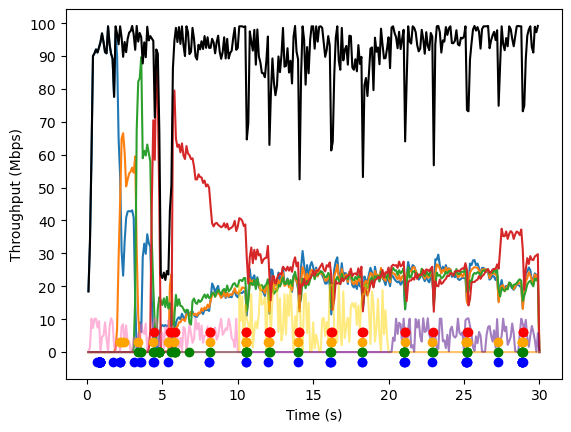

median ratio: 1.5290714492334394


([93.9749376,
  93.4487808,
  93.9868416,
  94.4296704,
  95.2510464,
  93.8773248,
  94.565376,
  93.660672,
  93.2749824,
  94.0368384,
  93.9749376],
 [1.5290714492334394,
  1.5688816855753644,
  1.1659055093189883,
  1.6510336777441594,
  1.6358921139765692,
  1.3514193773926766,
  1.7835905156191194,
  1.5383316624742136,
  1.1900709219858157,
  1.3702715075320602,
  1.5290714492334394],
 [1.6943854324734444,
  1.724295774647887,
  1.3787158145065397,
  1.7134615384615384,
  2.1395904436860067,
  1.8041278834479968,
  2.211400359066427,
  1.7265550994632144,
  1.2740399385560675,
  1.704853675945753,
  1.6943854324734444],
 [82.5148088888889,
  46.18206476190476,
  84.41091047619048,
  84.959072,
  81.18552888888888,
  86.488736,
  84.8936,
  83.36792888888888,
  85.86206476190476,
  83.82319157894737,
  82.5148088888889])

In [8]:
iteration = 1
taxConstant = "700000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

In [9]:
# iteration = 1
# taxConstant = "900000000"
# fifo_or_cebinae = "FIFO"
# protocol = "NewReno"
# raw_fifo = False
# show_plot = False

# # individual result arrays (experiment-iteration-specific)
# results_throughput = []
# results_median_fairness = []
# results_max_fairness = []
# results_median_time = []
# results_first2 = []

# while (iteration <= 1):
#     print("Round: " + str(iteration))
#     experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
#     results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
#     iteration += 1
        
# # individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
# if (not raw_fifo and (taxConstant not in labels)):
#     all_throughput_results.append(results_throughput)
#     all_median_fairness_results.append(results_median_fairness)
#     all_max_fairness_results.append(results_max_fairness)
#     all_first2_results.append(results_first2)

#     labels.append(taxConstant)
# else:
#     throughput_median_rawfifo = statistics.median(results_throughput)
# #     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
#     fairness_median_rawfifo = statistics.median(results_median_fairness)
#     fairness_max_rawfifo = statistics.median(results_max_fairness)

# print("throughput: " + str(statistics.mean(results_throughput)))
# print("median fairness: " + str(statistics.median(results_median_fairness)))
# print("max fairness: " + str(statistics.median(results_max_fairness)))
# # print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# # finding value nearest to median fairness value
# median_fairness = statistics.median(results_median_fairness)
# differences_array = []
# for item in results_median_fairness:
#     differences_array.append(abs(item - median_fairness))
# median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# # print(statistics.median(all_median_fairness_results))

# # identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
# show_plot = True
# experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# # showplot()
# plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.6808448
median fairness: 1.0858277702516639
max fairness: 1.2294151048072268


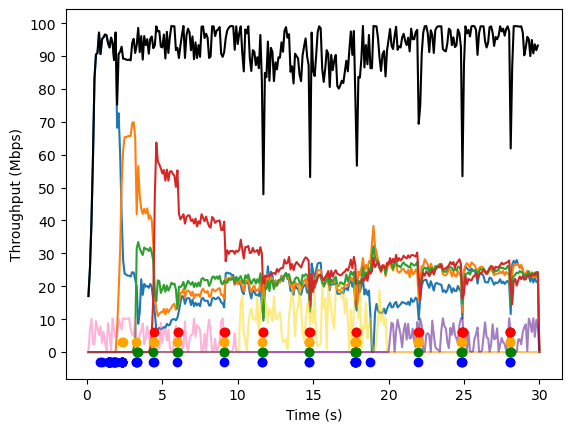

median ratio: 1.0690658904472081


([94.8844032,
  95.3724672,
  95.3415168,
  94.0582656,
  94.232064,
  95.0224896,
  94.9296384,
  94.4011008,
  93.7059072,
  94.8605952,
  95.3415168],
 [1.3230209281164695,
  1.0599948280320663,
  1.0690658904472081,
  1.6794910042305027,
  1.302325764123517,
  1.1025896500561196,
  1.068151683903474,
  1.040620957309185,
  1.345512730300664,
  1.0483242400623538,
  1.0690658904472081],
 [1.6487617718869898,
  1.194459681843116,
  1.2167278892342468,
  2.049568965517241,
  1.5743989603638726,
  1.2421023203802068,
  1.1877607788595272,
  1.153557046979866,
  1.6855036855036851,
  1.1931295645117663,
  1.2167278892342468],
 [82.08369454545455,
  81.94736,
  81.02888421052631,
  82.39856761904763,
  79.72398222222222,
  81.30453333333334,
  81.31020190476191,
  80.762912,
  81.05456,
  84.16716190476191,
  81.02888421052631])

In [10]:
iteration = 1
taxConstant = "1000000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.32658176
median fairness: 1.2540540297662406
max fairness: 1.3629827773039538


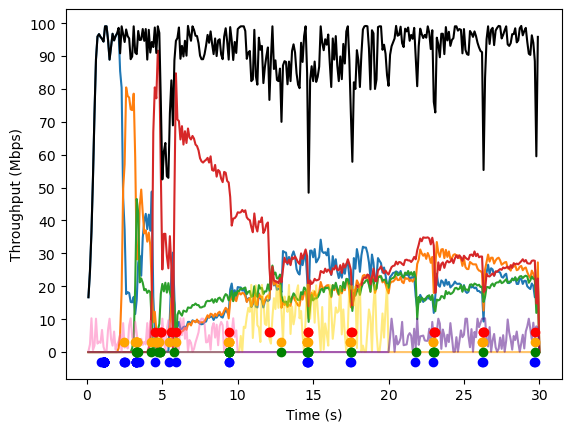

median ratio: 1.2560593099515256


([93.696384,
  94.148736,
  94.4725248,
  93.6201984,
  93.6273408,
  95.2153344,
  94.5796608,
  94.9748736,
  94.6772736,
  94.2534912,
  93.696384],
 [1.2560593099515256,
  1.4846919575184967,
  1.6206896551724137,
  1.2520487495809556,
  1.7393962793653035,
  1.2181549338254465,
  1.1744459969355177,
  1.0496711009122521,
  1.8690034950396668,
  1.0317704330002562,
  1.2560593099515256],
 [1.3614823815309844,
  1.521570961023505,
  1.7732603596559813,
  1.3644831730769231,
  1.8643152208452494,
  1.3247616295868245,
  1.2740849194729136,
  1.184980673660961,
  2.1247818499127398,
  1.129436882839605,
  1.3614823815309844],
 [81.465248,
  81.852128,
  80.01776761904762,
  80.989088,
  81.13447619047619,
  79.53219555555556,
  81.47371789473684,
  82.030688,
  80.45144888888889,
  81.096224,
  81.465248])

In [11]:
iteration = 1
taxConstant = "1100000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.03136256
median fairness: 1.2823655153662536
max fairness: 1.3779279993305988


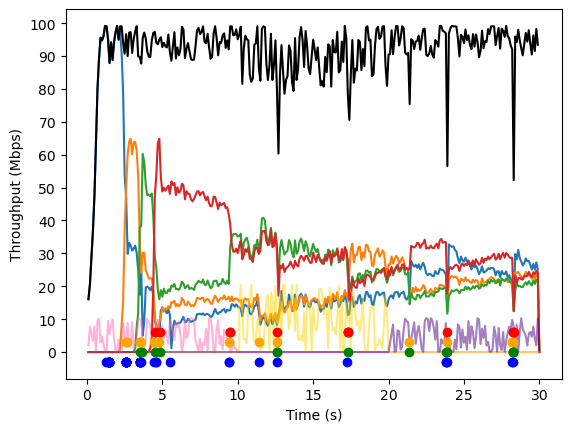

median ratio: 1.2787364726528225


([94.2701568,
  93.4844928,
  94.910592,
  93.7701888,
  94.19397120000001,
  93.7749504,
  93.5035392,
  93.2845056,
  94.3320576,
  94.7891712,
  94.2701568],
 [1.2787364726528225,
  1.358447631953518,
  1.2859945580796848,
  1.2223451327433628,
  1.1867495505523484,
  1.464057400935448,
  1.110422838674926,
  1.9357190174056786,
  1.1462675291711064,
  2.1811502241093934,
  1.2787364726528225],
 [1.3733689205219455,
  1.382487078139252,
  1.6903180706046839,
  1.281040268456376,
  1.233978729206436,
  1.6238418777022852,
  1.269587194608256,
  2.897684437264405,
  1.1846737070132682,
  2.2241980474198044,
  1.3733689205219455],
 [77.17214476190476,
  74.71976421052632,
  74.7322947368421,
  74.9160888888889,
  77.39321904761904,
  76.8660419047619,
  76.48057904761905,
  74.5130105263158,
  73.85795555555555,
  75.31852190476191,
  77.17214476190476])

In [12]:
iteration = 1
taxConstant = "1500000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.03160064
median fairness: 1.5357710878460251
max fairness: 1.588639048688489


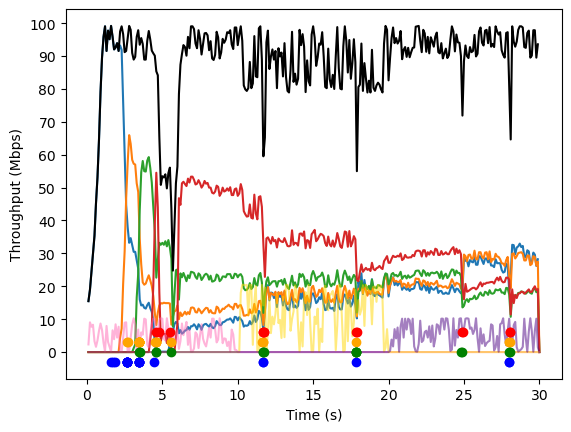

median ratio: 1.6524270118960351


([94.7058432,
  93.8225664,
  94.3225344,
  93.517824,
  94.2273024,
  93.6892416,
  93.613056,
  93.9035136,
  94.4844288,
  94.029696,
  93.613056],
 [1.3702890683262154,
  1.9877128349764897,
  1.2909678846017671,
  1.2009515813042262,
  1.9109861019192584,
  1.911436541143654,
  1.6524270118960351,
  1.4191151637960149,
  2.6732851985559565,
  1.1054377842093048,
  1.6524270118960351],
 [1.389034703995334,
  2.565185185185185,
  1.3128423615337799,
  1.4153125,
  1.9586693548387097,
  2.1118443904133377,
  1.727593507410021,
  1.449684589966957,
  2.8267066766691675,
  1.360783184566657,
  1.727593507410021],
 [68.37305263157894,
  69.751712,
  71.37886476190477,
  71.0330819047619,
  70.471904,
  70.495712,
  70.40048,
  71.57159619047619,
  69.38864,
  71.15779047619047,
  70.40048])

In [13]:
iteration = 1
taxConstant = "2000000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.8130432
median fairness: 1.4616264883421126
max fairness: 1.6263729367025896


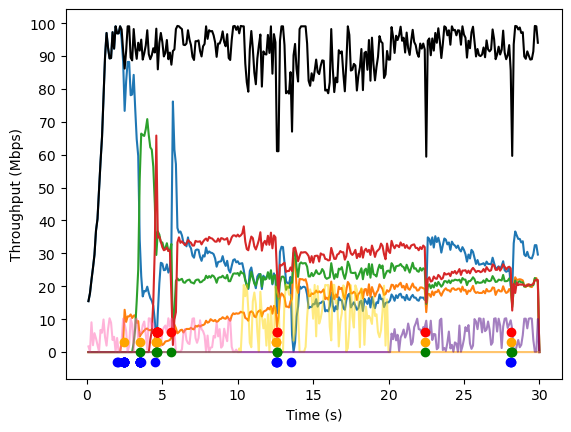

median ratio: 1.4687484443427894


([93.8820864,
  92.4774144,
  93.2178432,
  92.7297792,
  94.7010816,
  95.0439168,
  92.6702592,
  94.9201152,
  94.2582528,
  94.2296832,
  92.4774144],
 [1.421889551334159,
  1.4687484443427894,
  1.8344878170279535,
  1.9036337807885761,
  2.0991921834876663,
  1.3792348888746655,
  1.5352416707395393,
  1.3711097270980968,
  1.2632453611613528,
  1.4545045323414358,
  1.4687484443427894],
 [1.4988842843481034,
  1.512351620147578,
  2.3589648798521257,
  2.1048458149779736,
  2.2279666897987513,
  1.7908536585365857,
  1.740394253257601,
  1.407937928976425,
  1.2939601309134188,
  1.4692635423006697,
  1.512351620147578],
 [64.07945600000001,
  65.61392761904762,
  64.174688,
  62.07019789473684,
  47.945933333333336,
  62.34586947368421,
  62.615275789473685,
  62.734304,
  60.61144888888889,
  65.77831619047619,
  65.61392761904762])

In [14]:
iteration = 1
taxConstant = "2500000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.90565632
median fairness: 1.580776077281247
max fairness: 1.8684839151548094


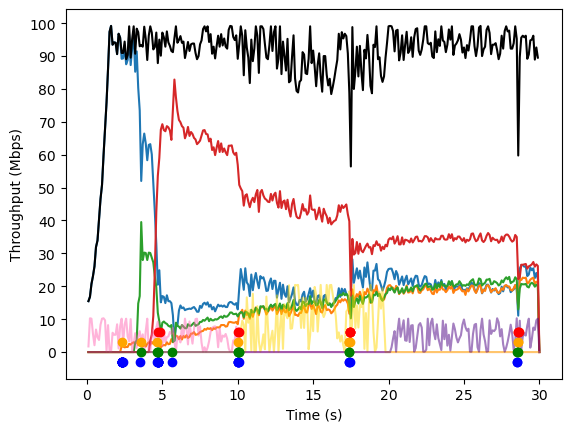

median ratio: 1.5279878687379997


([93.946368,
  92.4131328,
  94.4510976,
  93.7844736,
  93.3654528,
  95.0939136,
  93.0868992,
  94.291584,
  94.39872,
  94.2249216,
  93.3654528],
 [1.235042158629343,
  1.3944221743160057,
  2.5569937369519833,
  1.6335642858244943,
  1.5279878687379997,
  1.8963666609724155,
  1.808853671587522,
  1.4806273062730628,
  1.5076582052462968,
  1.7472054238553223,
  1.5279878687379997],
 [1.789913266945069,
  1.6386527141922826,
  2.8647540983606556,
  1.9191049913941483,
  1.8178628389154705,
  1.9320827943078915,
  1.9312449145646868,
  1.4935233160621764,
  1.7460140897293288,
  2.0514653323802716,
  1.8178628389154705],
 [55.76107789473684,
  57.01413052631579,
  60.09840761904762,
  56.017953684210525,
  60.03038476190476,
  53.548408888888886,
  59.19710476190476,
  57.859616,
  58.544096,
  59.180099047619045,
  60.03038476190476])

In [15]:
iteration = 1
taxConstant = "3000000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.73900032
median fairness: 1.824285242915706
max fairness: 2.2851609004725106


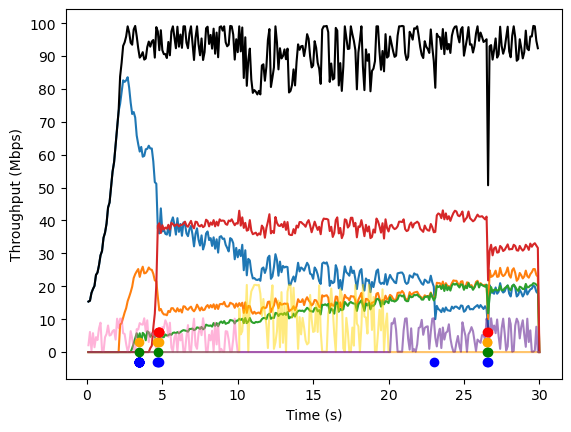

median ratio: 1.7185994217796337


([93.720192,
  93.09880319999999,
  94.2820608,
  93.5202048,
  94.005888,
  93.2297472,
  93.8487552,
  94.1773056,
  94.9201152,
  92.5869312,
  93.09880319999999],
 [1.428359096313912,
  1.7185994217796337,
  1.7035192563081007,
  1.248992515831894,
  2.447074010327022,
  1.9299710640517782,
  2.245218490247458,
  1.4045429057231749,
  2.2758387948418592,
  2.3977994075327973,
  1.7185994217796337],
 [1.5812637535366236,
  2.755659974369927,
  1.7102866779089374,
  1.295062102393214,
  2.5916740478299376,
  2.232693911592994,
  2.4028688524590165,
  1.4322284213980965,
  2.3376278893520275,
  2.4794220665499123,
  2.755659974369927],
 [34.09579789473684,
  35.795552,
  32.47832888888889,
  35.831264,
  34.08953263157895,
  37.5431619047619,
  34.114593684210526,
  37.52615619047619,
  34.09579789473684,
  35.831264,
  35.795552])

In [16]:
iteration = 1
taxConstant = "5000000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.99184128
median fairness: 1.9635636880527447
max fairness: 2.0749878640980075


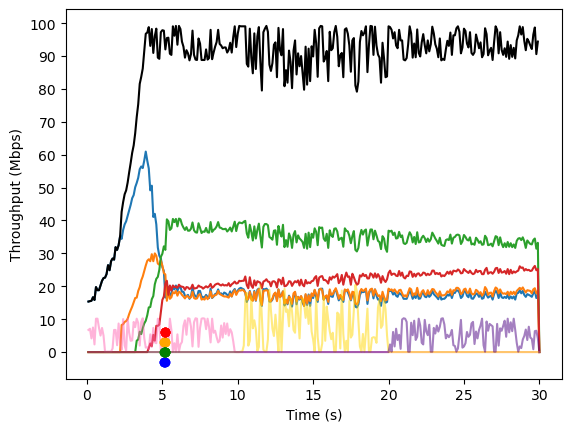

median ratio: 1.928843114009089


([94.7772672,
  92.9297664,
  93.75114239999999,
  93.6535296,
  94.8129792,
  94.51776,
  94.1320704,
  93.5344896,
  94.0582656,
  93.75114239999999,
  93.75114239999999],
 [2.106847322998507,
  2.1436503549073116,
  1.928843114009089,
  1.9982842620964005,
  1.3248542542506256,
  2.1370034721395927,
  1.6667718489822327,
  1.8772298006295909,
  2.237528222221426,
  1.394827754899774,
  1.928843114009089],
 [2.168141592920354,
  2.6220880069025023,
  1.9611650485436893,
  2.0606638687523846,
  1.373222748815166,
  2.38727634194831,
  1.7065390749601275,
  2.089311859443631,
  2.4052087322864804,
  1.3987138263665595,
  1.9611650485436893],
 [21.79082105263158,
  22.284512,
  22.759527619047617,
  21.797086315789475,
  22.284512,
  21.24888888888889,
  21.797086315789475,
  22.75385904761905,
  21.255502222222223,
  22.284512,
  22.759527619047617])

In [17]:
iteration = 1
taxConstant = "10000000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 92.34266112
median fairness: 6.132499065708194
max fairness: 6.27279487162075


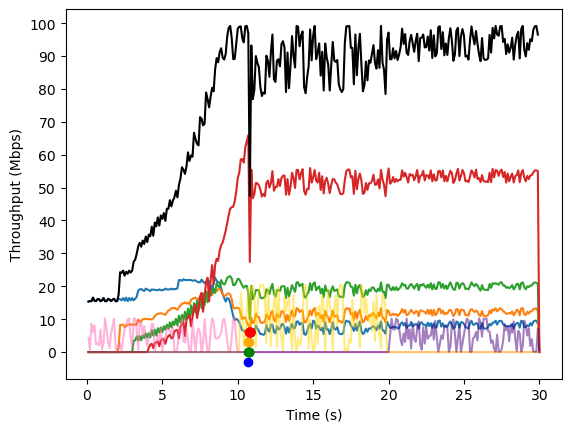

median ratio: 6.370056497175142


([93.1511808,
  94.148736,
  93.6273408,
  95.0367744,
  93.374976,
  94.0416,
  93.60591360000001,
  79.89250559999999,
  93.279744,
  93.26784,
  94.148736],
 [8.357567119399988,
  6.370056497175142,
  4.6643690979967065,
  5.231905910735827,
  8.115791822527077,
  5.894941634241245,
  7.416607879314086,
  3.815423976608187,
  7.481256451247451,
  5.1523171609610765,
  6.370056497175142],
 [8.71594982078853,
  6.6032568467801624,
  4.671779141104294,
  5.411949685534591,
  8.226771653543306,
  5.942332896461337,
  7.991338582677165,
  3.8228404099560755,
  8.038726333907057,
  5.407621247113164,
  6.6032568467801624],
 [15.787184761904761,
  15.767071999999999,
  15.798521904761904,
  15.782433684210526,
  15.767071999999999,
  15.798521904761904,
  15.799502222222221,
  15.767071999999999,
  15.786275555555555,
  15.767071999999999,
  15.767071999999999])

In [18]:
iteration = 1
taxConstant = "50000000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.89922816
median fairness: 6.5257126638639065
max fairness: 6.61900117258288


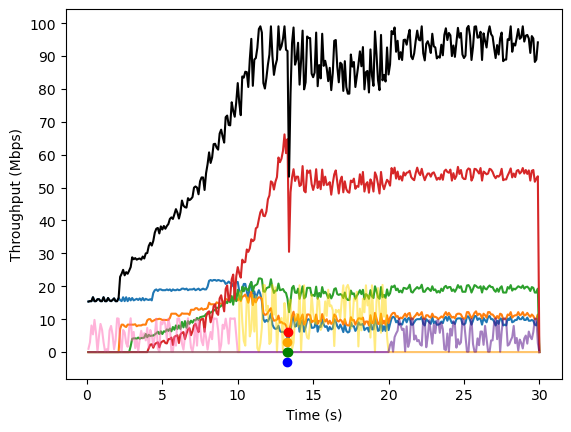

median ratio: 5.583843329253367


([93.2606976,
  94.291584,
  93.886848,
  93.3440256,
  93.0321408,
  95.2391424,
  93.9511296,
  93.9035136,
  93.5463936,
  94.5368064,
  94.291584],
 [14.297983331739328,
  5.583843329253367,
  22.25553319919517,
  9.251053034987937,
  4.668859649122807,
  7.467581998474447,
  4.323741007194244,
  8.416952054794521,
  5.034090909090909,
  5.553785945708755,
  5.583843329253367],
 [16.46865671641791,
  5.712578616352201,
  22.471428571428568,
  10.607981220657276,
  4.7016574585635365,
  7.52542372881356,
  4.362122788761707,
  8.601590106007066,
  5.221305841924398,
  5.6302992518703245,
  5.712578616352201],
 [15.767071999999999,
  15.798521904761904,
  15.782433684210526,
  15.782433684210526,
  15.782433684210526,
  15.767071999999999,
  15.792853333333333,
  15.799502222222221,
  15.782433684210526,
  15.767071999999999,
  15.798521904761904])

In [19]:
iteration = 1
taxConstant = "70000000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 86.10972672
median fairness: 9.4231955193908
max fairness: 9.673168449869399


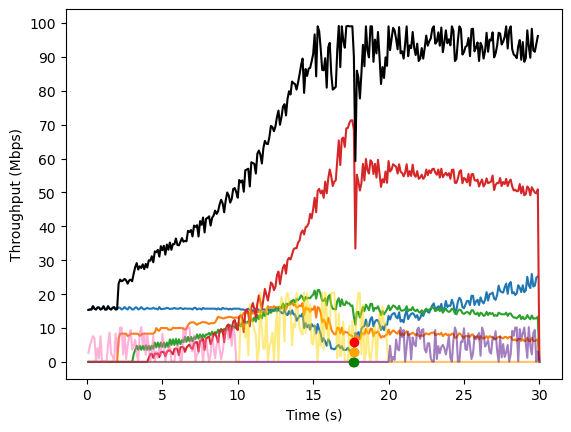

median ratio: 7.622749747823235


([93.5678208,
  92.5702656,
  22.5890304,
  93.5035392,
  92.113152,
  93.7011456,
  91.9322112,
  93.62496,
  93.791616,
  93.7035264,
  93.5678208],
 [7.622749747823235,
  5.881675456143542,
  3.2184014869888475,
  13.495118457412223,
  20.847457627118644,
  7.397702135210267,
  15.358493455861877,
  13.693633952254642,
  3.9952267303102635,
  11.223641290958366,
  7.622749747823235],
 [7.738698010849909,
  5.923132183908047,
  3.871268656716418,
  13.794117647058824,
  21.654867256637168,
  7.48902546093064,
  23.45351043643264,
  13.952445652173912,
  4.66359119943222,
  11.60763888888889,
  7.738698010849909],
 [15.773024,
  15.767071999999999,
  15.767071999999999,
  15.809859047619048,
  15.792853333333333,
  15.799502222222221,
  15.799502222222221,
  15.799502222222221,
  15.799502222222221,
  15.799502222222221,
  15.773024])

In [20]:
iteration = 1
taxConstant = "100000000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 38.98536192
median fairness: 2.0910530482977037
max fairness: 2.2309966216216215


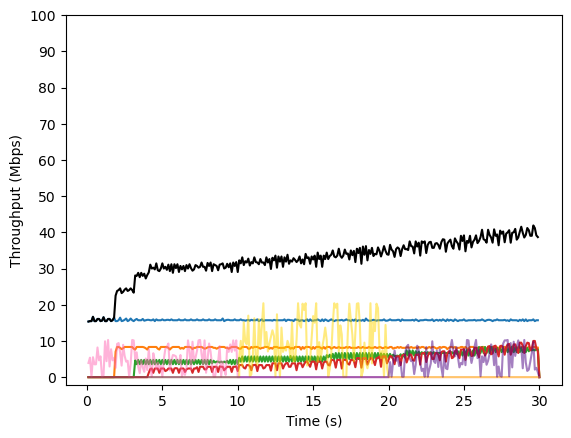

median ratio: 2.0910530482977037


([39.009408,
  38.9903616,
  38.9522688,
  38.9546496,
  38.9689344,
  38.9832192,
  38.973696000000004,
  38.997504,
  38.9903616,
  39.033216,
  38.9832192],
 [2.095162569389373,
  2.0902612826603324,
  2.0899363510843294,
  2.089972112289821,
  2.0887128852015113,
  2.0910530482977037,
  2.093576526566217,
  2.092783505154639,
  2.0910530482977037,
  2.093576526566217,
  2.0910530482977037],
 [2.233108108108108,
  2.2263513513513513,
  2.231418918918919,
  2.2271959459459456,
  2.233108108108108,
  2.2297297297297294,
  2.233108108108108,
  2.2297297297297294,
  2.230574324324324,
  2.233108108108108,
  2.2297297297297294],
 [15.799502222222221,
  15.804190476190476,
  15.782433684210526,
  15.798521904761904,
  15.767071999999999,
  15.799502222222221,
  15.767071999999999,
  15.799502222222221,
  15.787184761904761,
  15.782433684210526,
  15.799502222222221])

In [21]:
iteration = 1
taxConstant = "500000000000"
fifo_or_cebinae = "FIFO"
protocol = "NewReno"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFONewReno_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

In [22]:
iqr_throughput = []
iqr_median_fairness = []
iqr_max_fairness = []
iqr_time = []
iqr_util_first2 = []

q25_throughput = []
q25_median_fairness = []
q25_max_fairness = []
q25_time = []
q25_util_first2 = []

q75_throughput = []
q75_median_fairness = []
q75_max_fairness = []
q75_time = []
q75_util_first2 = []

q50_throughput = []
q50_median_fairness = []
q50_max_fairness = []
q50_time = []
q50_util_first2 = []

throughput_upper_error = []
median_fairness_upper_error = []
max_fairness_upper_error = []
util_first2_upper_error = []

throughput_lower_error = []
median_fairness_lower_error = []
max_fairness_lower_error = []
util_first2_lower_error = []


print(len(labels))

new_labels = []
for index in range(0, len(labels)):
#     new_labels.append(str(int(labels[index]) / 1000000000))
    new_labels.append(labels[index])
    
print(new_labels)
    
df_throughput = pd.DataFrame({label: result for label, result in zip(labels, all_throughput_results)})

df_median_fairness = pd.DataFrame({label: result for label, result in zip(labels, all_median_fairness_results)})

df_max_fairness = pd.DataFrame({label: result for label, result in zip(labels, all_max_fairness_results)})

df_util_first2 = pd.DataFrame({label: result for label, result in zip(labels, all_first2_results)})


#calculate interquartile range of values of throughput, fairness, time and store in iqr array
for value in labels:
    q75, q50, q25 = np.percentile(df_throughput[str(value)], [75,50, 25])
    iqr = q75 - q25
    iqr_throughput.append(iqr)
    q25_throughput.append(q25)
    q50_throughput.append(q50)
    q75_throughput.append(q75)

    q75, q50, q25 = np.percentile(df_median_fairness[value], [75,50, 25])
    iqr = q75 - q25
    iqr_median_fairness.append(iqr)
    q25_median_fairness.append(q25)
    q50_median_fairness.append(q50)
    q75_median_fairness.append(q75)
    
    q75, q50, q25 = np.percentile(df_max_fairness[value], [75,50, 25])
    iqr = q75 - q25
    iqr_max_fairness.append(iqr)
    q25_max_fairness.append(q25)
    q50_max_fairness.append(q50)
    q75_max_fairness.append(q75)
    
    q75, q50, q25 = np.percentile(df_util_first2[value], [75,50, 25])
    iqr = q75 - q25
    iqr_util_first2.append(iqr)
    q25_util_first2.append(q25)
    q50_util_first2.append(q50)
    q75_util_first2.append(q75)
    
for value in labels:
    throughput_upper_error.append(q75_throughput[labels.index(value)] - q50_throughput[labels.index(value)])
    throughput_lower_error.append(q50_throughput[labels.index(value)] - q25_throughput[labels.index(value)])
    
    median_fairness_upper_error.append(q75_median_fairness[labels.index(value)] - q50_median_fairness[labels.index(value)])
    median_fairness_lower_error.append(q50_median_fairness[labels.index(value)] - q25_median_fairness[labels.index(value)])

    max_fairness_upper_error.append(q75_max_fairness[labels.index(value)] - q50_max_fairness[labels.index(value)])
    max_fairness_lower_error.append(q50_max_fairness[labels.index(value)] - q25_max_fairness[labels.index(value)])
    
    util_first2_upper_error.append(q75_util_first2[labels.index(value)] - q50_util_first2[labels.index(value)])
    util_first2_lower_error.append(q50_util_first2[labels.index(value)] - q25_util_first2[labels.index(value)])

17
['50000000', '70000000', '100000000', '500000000', '700000000', '1000000000', '1100000000', '1500000000', '2000000000', '2500000000', '3000000000', '5000000000', '10000000000', '50000000000', '70000000000', '100000000000', '500000000000']


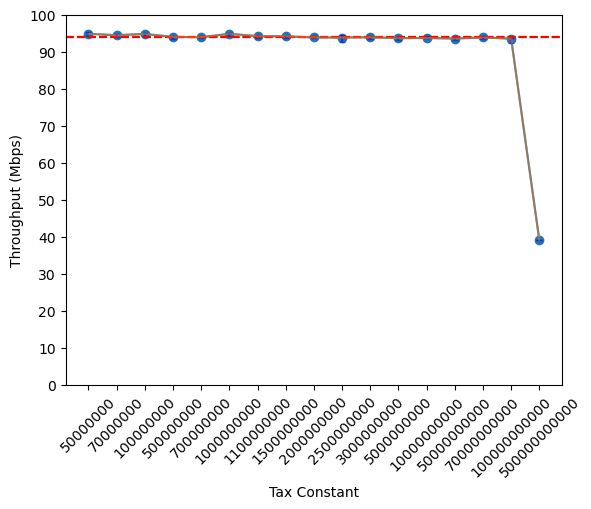

<Figure size 550x200 with 0 Axes>

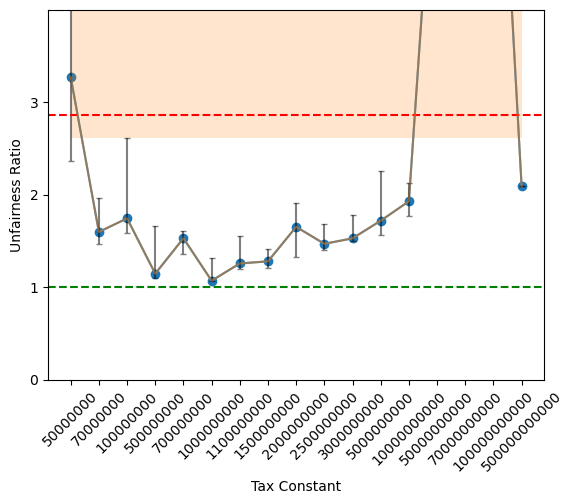

<Figure size 550x200 with 0 Axes>

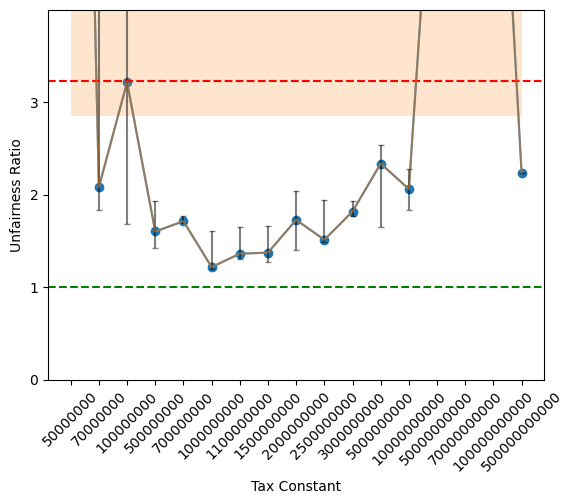

<Figure size 550x200 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [23]:
######################### Tax Constant vs Throughput  ###############
plt.xlabel('Tax Constant')
plt.ylabel('Throughput (Mbps)')
plt.scatter(new_labels, q50_throughput)
# # plt.scatter(new_labels, q50_util_first2)
plt.plot(new_labels, q50_throughput)
# plt.plot(new_labels, q50_util_first2)
plt.errorbar(new_labels, q50_throughput, yerr=[throughput_lower_error, throughput_upper_error], alpha=0.5, ecolor='blue', capsize=2)
# plt.errorbar(new_labels, q50_util_first2, yerr=[util_first2_lower_error, util_first2_upper_error], alpha=0.5, ecolor='black', capsize=2)
plt.axhline(y = throughput_median_rawfifo, color = 'r', linestyle = 'dashed')
plt.axhline(y = throughput_median_rawfifo, color = 'r', linestyle = 'dashed')
plt.axhline(y = throughput_median_rawfifo, color = 'r', linestyle = 'dashed')
yticks = np.arange(0, 110, 10)
plt.yticks(yticks)
plt.xticks(rotation=45, ha="center")
plt.figure(figsize=(5.5, 2))
plt.show()
plt.clf()

######################### Tax Constant vs Median Fairness Ratio ###############
plt.xlabel('Tax Constant')
plt.ylabel('Unfairness Ratio')
plt.scatter(new_labels, q50_median_fairness)
plt.plot(new_labels, q50_median_fairness)
plt.errorbar(new_labels, q50_median_fairness, yerr=[median_fairness_lower_error, median_fairness_upper_error], alpha=0.5, ecolor='black', capsize=2)
plt.axhline(y = fairness_median_rawfifo, color = 'r', linestyle = 'dashed')
plt.axhline(y = 1, color = 'g', linestyle = 'dashed')
plt.fill_between(new_labels, 4.11361720933764, 2.61468217548715, alpha=0.2)
yticks = np.arange(0, 4, 1)
plt.yticks(yticks)
plt.xticks(rotation=45, ha="center")
plt.ylim(0, 4)
plt.figure(figsize=(5.5, 2))
plt.show()
plt.clf()

######################### Tax Constant vs Max Fairness Ratio ###############
plt.xlabel('Tax Constant')
plt.ylabel('Unfairness Ratio')
plt.scatter(new_labels, q50_max_fairness)
plt.plot(new_labels, q50_max_fairness)
plt.errorbar(new_labels, q50_max_fairness, yerr=[max_fairness_lower_error, max_fairness_upper_error], alpha=0.5, ecolor='black', capsize=2)
plt.axhline(y = fairness_max_rawfifo, color = 'r', linestyle = 'dashed')
plt.axhline(y = 1, color = 'g', linestyle = 'dashed')
plt.fill_between(new_labels, 4.699445553396953, 2.847744529609219, alpha=0.2)
yticks = np.arange(0, 4, 1)
plt.yticks(yticks)
plt.xticks(rotation=45, ha="center")
plt.ylim(0, 4)
plt.figure(figsize=(5.5, 2))
plt.show()
plt.clf()